Name GitHub Projekt: "Disaster Tweet Classification: An NLP Pipeline"

# Problem Statement

Social media platforms like Twitter have become critical communication channels
during natural disasters and emergency situations. However, not every tweet
containing disaster-related language actually describes a real event. Many use
such language in a non-literal way (i.e. metaphoric, hypothetic).

The goal of this project is to build a text classification model that
distinguishes between tweets reporting real disasters and those that do not.
The dataset consists of 7,613 labeled tweets and was originally compiled
for binary text classification research.

Accurate classification has real-world relevance: automated disaster detection
systems could help emergency services and journalists identify critical
information faster during crises.

# Dataset overview

In [1]:
import pandas as pd

# Load the dataset
path = 'Data/'
df = pd.read_csv(path + 'train.csv')

# Display shape and first rows
print(df.shape)
df.head(20)

(7613, 2)


,text,target
0,Our Deeds are the Reason of this #earthquake M...,1
1,Forest fire near La Ronge Sask. Canada,1
2,All residents asked to 'shelter in place' are ...,1
3,"13,000 people receive #wildfires evacuation or...",1
4,Just got sent this photo from Ruby #Alaska as ...,1
5,#RockyFire Update => California Hwy. 20 closed...,1
6,#flood #disaster Heavy rain causes flash flood...,1
7,I'm on top of the hill and I can see a fire in...,1
8,There's an emergency evacuation happening now ...,1
9,I'm afraid that the tornado is coming to our a...,1


In [2]:
# Check for missing values per column
df.isnull().sum()

text      0
target    0
dtype: int64

In [3]:
# Check for values in target column
df['target'].unique()

array([1, 0])

target
0    4342
1    3271
Name: count, dtype: int64


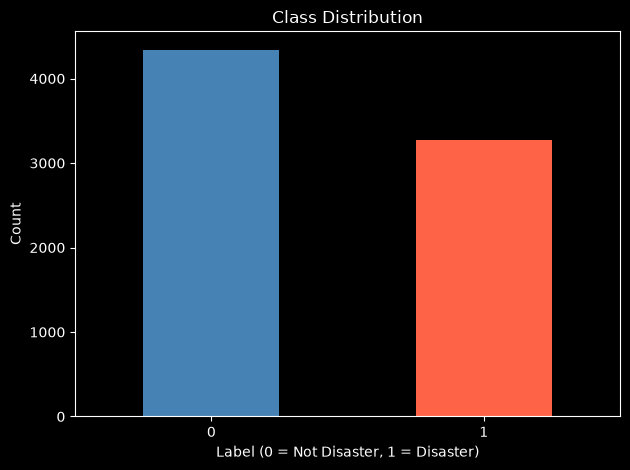

In [4]:
import matplotlib.pyplot as plt

# Inspect class distribution
class_counts = df["target"].value_counts()
print(class_counts)

# Visualize class distribution
class_counts.plot(
    kind="bar",
    color=["steelblue", "tomato"]
)
plt.title("Class Distribution")
plt.xlabel("Label (0 = Not Disaster, 1 = Disaster)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
class_distribution = pd.DataFrame({
    "count": df["target"].value_counts(),
    "percent": df["target"].value_counts() / len(df) * 100
})

print(class_distribution.round(1))

        count  percent
target                
0        4342     57.0
1        3271     43.0


**Observations**

- The dataset contains 7,613 tweets across two columns: text and target
- The target variable is binary, with 1 indicating a real disaster tweet and 0 indicating a non-disaster tweet.

- The class distribution is moderately imbalanced: 57% of tweets are labeled as non-disaster and 43% as disaster.
- This imbalance is relevant for the choice of evaluation metrics and will be addressed in the model evaluation section.

# Preprocessing
## Character inspection

In [6]:
import re

# Show tweets containing non-ASCII characters
mask = df["text"].apply(lambda x: bool(re.search(r"[^\x00-\x7F]", x)))
print(f"{mask.sum()} tweets contain non-ASCII characters")
df[mask]["text"].head(10)

697 tweets contain non-ASCII characters


38     Barbados #Bridgetown JAMAICA ÛÒ Two cars set ...
52     SANTA CRUZ ÛÓ Head of the St Elizabeth Police...
53     Police: Arsonist Deliberately Set Black Church...
57     Set our hearts ablaze and every city was a gif...
71     #stlouis #caraccidentlawyer Speeding Among Top...
87     RT nAAYf: First accident in years. Turning ont...
104    320 [IR] ICEMOON [AFTERSHOCK] | http://t.co/yN...
106    320 [IR] ICEMOON [AFTERSHOCK] | http://t.co/vA...
114    320 [IR] ICEMOON [AFTERSHOCK] | http://t.co/M4...
115    320 [IR] ICEMOON [AFTERSHOCK] | http://t.co/vA...
Name: text, dtype: str

In [7]:
# Count tweets containing any Û-based encoding artifact
mask_artifacts = df["text"].str.contains("Û", regex=False)
print(f"{mask_artifacts.sum()} tweets contain Û-based encoding artifacts")

612 tweets contain Û-based encoding artifacts


**Character Inspection**

- Before defining the preprocessing pipeline, the raw text was inspected for non-ASCII characters.
    - ASCII is a character encoding standard covering 128 characters: the Latin alphabet, digits, basic punctuation and control characters. Everything beyond this range, such as emojis, Arabic or Chinese script, and typographic special characters, is considered non-ASCII.
- Of the 7,613 tweets in the dataset, 697 contained non-ASCII characters.
    - Manual inspection revealed 612 tweets (8.0% of the dataset) containing encoding artifacts from the Twitter API, appearing as character sequences such as ÛÒ or ÛÓ, with no recoverable semantic content.
- All non-ASCII characters are therefore removed as the first preprocessing step.

## Preprocessing Pipeline

In [8]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove non-ASCII characters (encoding artifacts and emojis)
    text = re.sub(r"[^\x00-\x7F]", "", text)
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    # Remove mention symbols and hashtag symbols but keep the text
    text = re.sub(r"[@#]", "", text)
    # Remove punctuation and numbers
    text = re.sub(r"[^a-z\s]", "", text)
    # Remove extra whitespace
    text = " ".join(text.split())
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    stop_words = set(stopwords.words("english"))
    tokens = [t for t in tokens if t not in stop_words]
    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df["text_clean"] = df["text"].apply(preprocess_text)

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/matthiasmuschket/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/matthiasmuschket/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/matthiasmuschket/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/matthiasmuschket/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [9]:
df.head()

,text,target,text_clean
0,Our Deeds are the Reason of this #earthquake M...,1,deed reason earthquake may allah forgive u
1,Forest fire near La Ronge Sask. Canada,1,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,1,resident asked shelter place notified officer ...
3,"13,000 people receive #wildfires evacuation or...",1,people receive wildfire evacuation order calif...
4,Just got sent this photo from Ruby #Alaska as ...,1,got sent photo ruby alaska smoke wildfire pour...


**The preprocessing pipeline applies the following steps in order:**

- Lowercase conversion: ensures identical words are not treated as distinct tokens
- Non-ASCII removal: eliminates encoding artifacts introduced by the Twitter API
- URL removal: URLs carry no semantic information relevant to classification
- Mention and hashtag symbol removal: the symbols @ and # are stripped while preserving the underlying text, since hashtag content such as "wildfire" or "earthquake" may carry relevant signal for the classifier
- Punctuation and digit removal: TF-IDF operates on word tokens and these characters do not contribute meaningful features in this context
- Whitespace normalization: after removal of URLs, symbols and punctuation, multiple consecutive whitespace characters are collapsed into a single space
- Tokenization: splits text into individual word tokens
- Stopword removal: reduces noise from high-frequency function words
- Lemmatization: reduces words to their base dictionary form, preferred over stemming because it produces readable, valid word forms that support interpretability of TF-IDF feature weights

# Tweet Classification via Machine Learning
## Train-Test Split

In [10]:
from sklearn.model_selection import train_test_split

# Define feature and target variables
X = df["text_clean"]
y = df["target"]

# Split data before vectorization to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

- stratify=y: ensures that the class distribution of the original dataset is preserved in both training and test set, preventing an accidental imbalance that could bias model training or evaluation

## Vectorization: TF-IDF

For vectorization, TF-IDF (Term Frequency-Inverse Document Frequency) is used.
TF-IDF weights each term by how frequently it appears in a given document
relative to how commonly it appears across the entire corpus. Terms that are
frequent in a specific tweet but rare across all tweets receive a high weight,
making them strong discriminative features.

The following TF-IDF parameters are optimized during hyperparameter tuning
in Section 5:

- max_features: limits the vocabulary to the most frequent terms, reducing
  dimensionality while retaining the most informative tokens. Values tested:
  3000, 5000, 10000.
- ngram_range: defines whether only single words (unigrams) or also
  multi-word sequences (bigrams, trigrams) are included as features. Values
  tested: (1,1), (1,2), (1,3), (1,4).

## Why TF-IDF

- For short, keyword-driven texts such as tweets, TF-IDF is particularly effective: domain-specific terms like "wildfire" or "earthquake" appear rarely across the corpus but frequently in disaster tweets, receiving high weights as a result
- Bag-of-Words was dismissed as it treats all words as equally important and ignores document-level weighting
- Transformer-based models could handle ambiguous language better, but without fine-tuning the expected gain is modest and the added complexity not justified given the scope of this project
-
- TF-IDF requires word-level features and is therefore paired with a word tokenizer (NLTKs word_tokenize). Subword tokenizers such as BPE or WordPiece are tightly coupled to Transformer architectures and incompatible with TF-IDF.
- One fundamental limitation of TF-IDF is its inability to capture contextual meaning. "Bank" carries an entirely different meaning in "river bank" versus "financial institution", yet TF-IDF assigns the same feature weight in both cases. This limitation is revisited in the error analysis section.

## Why Logistic Regression

* Logistic Regression is a well-established baseline for text classification
  tasks and pairs naturally with TF-IDF feature matrices
* It outputs class probabilities rather than hard labels, which enables
  threshold optimization as discussed in Section "Threshold Selection for Disaster Detection"
* Coefficients are directly interpretable: each feature weight indicates the
  contribution of a term to the predicted class, enabling meaningful feature
  importance analysis as discussed in Section "Feature Importance"
* It generalizes reliably on high-dimensional sparse data such as TF-IDF
  matrices without requiring feature scaling
* Model training takes place within the hyperparameter tuning pipeline in
  Section 5, where TF-IDF vectorization and Logistic Regression are combined
  to prevent data leakage across cross-validation folds

# Hyperparameter Tuning

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Define hyperparameters to test
ngram_sizes = [1, 2, 3, 4]
max_features_options = [3000, 5000, 10000]
C_values = [0.1, 1, 10]

# Initialize placeholders for best configuration
best_score = -1.0
best_params = {}

# Loop through all combinations of hyperparameters
for n in ngram_sizes:
    for max_feat in max_features_options:
        for C in C_values:

            # Build pipeline to prevent data leakage:
            # vectorizer is fitted only on training folds, never on validation fold
            pipeline = Pipeline([
                ("tfidf", TfidfVectorizer(ngram_range=(1, n), max_features=max_feat)),
                ("clf", LogisticRegression(max_iter=1000, C=C))
            ])

            # 10-fold cross-validation with weighted F1 as evaluation metric
            # n_jobs=-1 uses all available CPU cores for parallelization
            f1_scores = cross_val_score(
                pipeline,
                X_train,
                y_train,
                cv=10,
                scoring="f1_weighted",
                n_jobs=-1
            )

            avg_f1 = f1_scores.mean()

            # Print result for current combination
            print(f"ngram: (1,{n}), max_features: {max_feat}, C: {C} => F1: {avg_f1:.3f}")

            # Update best configuration if current result improves on best score
            if avg_f1 > best_score:
                best_score = avg_f1
                best_params = {
                    "ngram": n,
                    "max_features": max_feat,
                    "C": C
                }

# Print best configuration found
print("\nBest Configuration:")
print(best_params)
print(f"Best weighted F1: {best_score:.3f}")

ngram: (1,1), max_features: 3000, C: 0.1 => F1: 0.712
ngram: (1,1), max_features: 3000, C: 1 => F1: 0.791
ngram: (1,1), max_features: 3000, C: 10 => F1: 0.773
ngram: (1,1), max_features: 5000, C: 0.1 => F1: 0.695
ngram: (1,1), max_features: 5000, C: 1 => F1: 0.794
ngram: (1,1), max_features: 5000, C: 10 => F1: 0.777
ngram: (1,1), max_features: 10000, C: 0.1 => F1: 0.677
ngram: (1,1), max_features: 10000, C: 1 => F1: 0.794
ngram: (1,1), max_features: 10000, C: 10 => F1: 0.777
ngram: (1,2), max_features: 3000, C: 0.1 => F1: 0.716
ngram: (1,2), max_features: 3000, C: 1 => F1: 0.791
ngram: (1,2), max_features: 3000, C: 10 => F1: 0.775
ngram: (1,2), max_features: 5000, C: 0.1 => F1: 0.696
ngram: (1,2), max_features: 5000, C: 1 => F1: 0.793
ngram: (1,2), max_features: 5000, C: 10 => F1: 0.777
ngram: (1,2), max_features: 10000, C: 0.1 => F1: 0.673
ngram: (1,2), max_features: 10000, C: 1 => F1: 0.795
ngram: (1,2), max_features: 10000, C: 10 => F1: 0.783
ngram: (1,3), max_features: 3000, C: 0.1

## Results

- Using 10-fold cross-validation with weighted F1 as evaluation metric, the grid search tested
    - (a) all combinations of ngram range (1,1) to (1,4),
    - (b) max_features (3000, 5000, 10000) and
    - (c) regularization strength C (0.1, 1, 10)
- The best configuration is ngram_range=(1,2), max_features=10000, C=1 with a weighted F1 of 0.795.

**Key observations**
- C=1 consistently outperforms both C=0.1 and C=10 across all combinations.
    - C=0.1 leads to underfitting (too strong regularization), C=10 to slight overfitting (too weak regularization).
    - The default value of C=1 proves to be the appropriate regularization strength for this dataset.
- The ngram range has negligible impact on performance.
    - Scores at C=1 are virtually identical across (1,1) to (1,4), suggesting that higher-order n-grams provide little additional signal for short texts such as tweets, where long recurring phrases are rare.
- max_features shows a small but consistent positive effect at C=1:
    - larger vocabularies marginally improve performance, suggesting that retaining more terms adds useful signal without introducing excessive noise.
- The overall spread between best and worst configuration at C=1 is only 0.006 F1 points, indicating that the model is robust to the choice of TF-IDF parameters as long as regularization is set appropriately.

## Retrain final model with best hyperparameters found during tuning

In [12]:
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, best_params["ngram"]),
    max_features=best_params["max_features"]
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

logistic_regression_tuned = LogisticRegression(
    max_iter=1000,
    C=best_params["C"]
).fit(X_train_tfidf, y_train)

# Check number of iterations until convergence
print(f"The model converges after {logistic_regression_tuned.n_iter_[0]} iterations.")

The model converges after 27 iterations.


In [13]:
# Inspect a readable excerpt as DataFrame
feature_names = tfidf_vectorizer.get_feature_names_out()

# First 5 samples, all features
df_tfidf = pd.DataFrame(
    X_train_tfidf[:5].toarray(),
    columns=feature_names
)

df_tfidf

,ab,aba,aba woman,abandon,abandoned,abandoned aircraft,abbott,abbswinston,abbswinston zionist,abc,...,zero,zimbabwe,zionist,zionist terrorist,zipper,zipper bag,zombie,zone,zone coming,zouma
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Model evaluation
## Why F1-Score

- The dataset is moderately imbalanced (57% / 43%). Accuracy would treat all errors as equally costly, which is inappropriate in a disaster detection context where a missed disaster carries a fundamentally different consequence than a false alarm.
- F1 score balances precision and recall, penalizing both false positives (false alarms) and false negatives (missed disasters)
- As evaluation metric, the weighted average F1 score is used. It combines the F1 scores of both classes weighted by their support, thereby reflecting the actual class distribution while accounting for both precision and recall.

## Predict labels for the test data

In [14]:
y_pred = logistic_regression_tuned.predict(X_test_tfidf)

print(y_pred)

[1 0 1 ... 1 0 0]


## Cross-Validation (Training Data)

In [15]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# 10-fold cross-validation on training data
f1_scores_list = cross_val_score(
    LogisticRegression(max_iter=1000, C=best_params["C"]),
    X_train_tfidf,
    y_train,
    cv=10,
    scoring="f1_weighted"
)

print(f"F1 Scores per fold: {f1_scores_list}")
print("F1 Score Mean: {:.3f}".format(f1_scores_list.mean()))
print("F1 Score Std: {:.3f}".format(f1_scores_list.std()))

F1 Scores per fold: [0.76382455 0.8105927  0.79184766 0.8098085  0.80658393 0.75752156
 0.79155866 0.80267048 0.79560703 0.8105306 ]
F1 Score Mean: 0.794
F1 Score Std: 0.018


**INTERPRETATION**
- 10-fold cross-validation on the training data yields a mean F1 score of 0.794 with a standard deviation of 0.018.
- The low standard deviation indicates:
  - (a) a consistent model performs across different subsets of the training data
  - (b) stable generalization behavior of the model

## Evaluation on Test Set

              precision    recall  f1-score   support

           0       0.80      0.90      0.85       869
           1       0.84      0.71      0.77       654

    accuracy                           0.82      1523
   macro avg       0.82      0.80      0.81      1523
weighted avg       0.82      0.82      0.81      1523



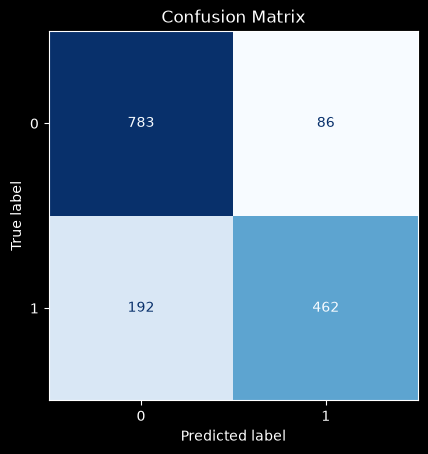

                      Predicted: Not Disaster  Predicted: Disaster
Actual: Not Disaster                      783                   86
Actual: Disaster                          192                  462


In [16]:
# Evaluation on held-out test set
print(classification_report(y_test, y_pred))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, colorbar=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# Confusion matrix as DataFrame
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual: Not Disaster", "Actual: Disaster"],
    columns=["Predicted: Not Disaster", "Predicted: Disaster"]
)
print(cm_df)

**Results and Discussion**
- 10-fold cross-validation on the training data yields a weighted average F1 score of 0.794 with a standard deviation of 0.018. The low standard deviation indicates consistent performance across folds, suggesting good generalisation.
- On the held-out test set the model achieves a weighted average F1 score of 0.81. The cross-validation estimate of 0.794 and the test set result of 0.81 are in a comparable range, suggesting no significant overfitting.

- The results differ between the two classes:
    - Class 0 (Not Disaster): precision 0.80, recall 0.90, F1 0.85. The model identifies non-disaster tweets reliably, missing only 86 out of 869 cases.
    - Class 1 (Disaster): precision 0.84, recall 0.71, F1 0.77. While precision is high, recall is notably lower: 192 out of 654 actual disaster tweets were misclassified as non-disasters (false negatives).

The asymmetry between classes is relevant in a real-world context. A false negative, meaning a missed disaster tweet, is considerably more costly than a false positive. Emergency services relying on such a classifier would prefer
higher recall on the disaster class, potentially at the cost of precision. This trade-off is addressed in the following section on threshold selection.

# Threshold Selection for Disaster Detection

## Rationale
- The evaluation above reports performance at the default classification probability threshold of 0.5, meaning all tweets with a predicted disaster probability above 0.5 are classified as disaster.
- The following section explores how adjusting this threshold affects the trade-off between precision and recall for the disaster class, motivated by the real-world asymmetry of error costs.
- A minimum recall of 0.85 for the disaster class is desired as the selection criterion, reflecting the assumption that missing at most 15% of actual disaster tweets is an acceptable upper bound in a real-world detection context.

## Recall & Precision vs. Classification Threshold

     threshold  precision    recall
655   0.352572   0.666268  0.851682
656   0.353139   0.667066  0.851682
657   0.353273   0.667866  0.851682
658   0.353331   0.668667  0.851682
659   0.353479   0.669471  0.851682
660   0.353920   0.670277  0.851682
661   0.353997   0.671084  0.851682
662   0.354333   0.671894  0.851682
663   0.354374   0.672705  0.851682
664   0.354482   0.673519  0.851682
665   0.355077   0.674334  0.851682
666   0.355195   0.675152  0.851682
667   0.356887   0.675971  0.851682
668   0.356973   0.676792  0.851682
669   0.357196   0.677616  0.851682
670   0.358345   0.679268  0.851682
671   0.358350   0.678877  0.850153
672   0.358454   0.678484  0.848624



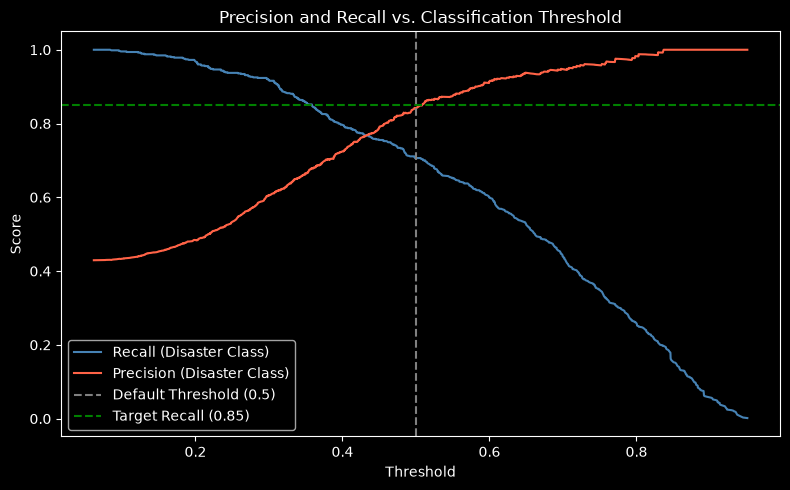

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, classification_report

# Get predicted probabilities for disaster class (label 1)
y_prob = logistic_regression_tuned.predict_proba(X_test_tfidf)[:, 1]

# Compute precision and recall for all thresholds
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

# Store precision, recall and thresholds as DataFrame for inspection
pr_df = pd.DataFrame({
    "threshold": pr_thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

print(pr_df[(pr_df["recall"] >= 0.848) & (pr_df["recall"] <= 0.852)])
print()

# Plot Recall and Precision against threshold
plt.figure(figsize=(8, 5))
plt.plot(pr_thresholds, recall[:-1], label="Recall (Disaster Class)", color="steelblue")
plt.plot(pr_thresholds, precision[:-1], label="Precision (Disaster Class)", color="tomato")
plt.axvline(x=0.5, color="gray", linestyle="--", label="Default Threshold (0.5)")
plt.axhline(y=0.85, color="green", linestyle="--", label="Target Recall (0.85)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs. Classification Threshold")
plt.legend()
plt.tight_layout()
plt.show()

## Threshold selection

In [18]:
# Define minimum acceptable recall for the disaster class
target_recall = 0.85

# Filter all threshold candidates where recall meets the target
valid = pr_df[pr_df["recall"] >= target_recall]

# Sort valid candidates by precision descending and select the best row
best_row = valid.sort_values("precision", ascending=False).iloc[0]

# Extract the selected threshold value
best_threshold = best_row["threshold"]

# Apply selected threshold to generate optimized predictions
# .astype(int) converts boolean array (True/False) to integer array (1/0)
# consistent with y_pred and y_test
print(y_prob)
y_pred_optimized = (y_prob >= best_threshold).astype(int)

# Compare classification reports for default vs selected threshold
print("\nDefault threshold (0.50):")
print(classification_report(y_test, y_pred))

print(f"\nSelected threshold ({best_threshold:.3f}):")
print(classification_report(y_test, y_pred_optimized))

# Print key metrics at selected threshold
print(f"Selected threshold for disaster class recall >= 0.85: {best_threshold:.3f}")
print(f"Actual recall at selected threshold: {best_row['recall']:.3f}")
print(f"Precision at selected threshold: {best_row['precision']:.3f}")

[0.53431673 0.30739876 0.70581615 ... 0.51482957 0.26132531 0.26382473]

Default threshold (0.50):
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       869
           1       0.84      0.71      0.77       654

    accuracy                           0.82      1523
   macro avg       0.82      0.80      0.81      1523
weighted avg       0.82      0.82      0.81      1523


Selected threshold (0.358):
              precision    recall  f1-score   support

           0       0.86      0.70      0.77       869
           1       0.68      0.85      0.76       654

    accuracy                           0.76      1523
   macro avg       0.77      0.77      0.76      1523
weighted avg       0.78      0.76      0.76      1523

Selected threshold for disaster class recall >= 0.85: 0.358
Actual recall at selected threshold: 0.852
Precision at selected threshold: 0.679


In [19]:
# Combine predicted probabilities and labels into a DataFrame for inspection
pred_df = pd.DataFrame({
    "y_prob": y_prob,
    "y_predicted_threshold_0_5": y_pred,
    f"y_pred_threshold_{best_threshold:.3f}".replace(".", "_"): y_pred_optimized,
    "y_true": y_test.values
})

pred_df.head(10)

,y_prob,y_predicted_threshold_0_5,y_pred_threshold_0_358,y_true
0,0.534317,1,1,0
1,0.307399,0,0,0
2,0.705816,1,1,1
3,0.255778,0,0,0
4,0.106713,0,0,0
5,0.217768,0,0,1
6,0.471012,0,1,1
7,0.095556,0,0,1
8,0.241218,0,0,0
9,0.185344,0,0,0


In [20]:
# Confusion Matrix for optimized classification threshold
cm_optimized = confusion_matrix(y_test, y_pred_optimized)
cm_optimized_df = pd.DataFrame(
    cm_optimized,
    index=["Actual: Not Disaster", "Actual: Disaster"],
    columns=["Predicted: Not Disaster", "Predicted: Disaster"]
)
print(cm_optimized_df)

                      Predicted: Not Disaster  Predicted: Disaster
Actual: Not Disaster                      606                  263
Actual: Disaster                           97                  557


## Interpretation
- Among all classification thresholds ensuring a minimum recall of 0.85, the one maximizing precision for the disaster class was selected, yielding a threshold of 0.358 with an actual recall of 0.852.

- At the default threshold of 0.50, the model misses 192 out of 654 actual disaster tweets (false negatives), achieving a recall of 0.71 for the disaster class
- Lowering the threshold to 0.358 reduces missed disasters from 192 to 97, increasing recall for the disaster class to 0.85
- This comes at a cost: false alarms increase from 86 to 263, meaning precision for the disaster class drops from 0.84 to 0.68
- The weighted average F1 score decreases from 0.81 to 0.76, reflecting the precision loss
- In a real-world disaster detection context, this trade-off is justified: a missed disaster carries a fundamentally higher cost than a false alarm. The selected threshold of 0.358 is therefore preferable for deployment despite the lower overall F1 score

**Limitation**
The classification threshold was selected based on the test set precision-recall
curve. Ideally, threshold selection would be performed on a separate validation
set (a subset of the training data held out exclusively for this purpose) to
ensure that the evaluation on the test set remains unbiased. Within the scope
of this project this limitation is accepted and noted here explicitly. The
reported performance at the selected threshold should therefore be interpreted
as optimistic.

# Model Interpretation and Error Analysis
## Feature Importance
### ... Overview in Dataframes

In [21]:
import pandas as pd

# Extract feature names and model coefficients
feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = logistic_regression_tuned.coef_[0]

# Create DataFrame with all features and corresponding coefficients
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

# Disaster class: highest positive coefficients
top_disaster = feature_importance.sort_values("coefficient", ascending=False).copy()
top_disaster["class"] = "disaster"

# Non-disaster class: highest negative coefficients
top_non_disaster = feature_importance.sort_values("coefficient", ascending=True).copy()
top_non_disaster["class"] = "non_disaster"

# Display top features for each class
print(top_disaster.head(20))
print()
print(top_non_disaster.head(20))

         feature  coefficient     class
2952        fire     3.391319  disaster
3763   hiroshima     3.255460  disaster
1132  california     2.620625  disaster
9710    wildfire     2.468368  disaster
9042       train     2.386756  disaster
3039       flood     2.321265  disaster
8465       storm     2.310382  disaster
4377      killed     2.200473  disaster
2398  earthquake     2.178276  disaster
893      bombing     2.115729  disaster
8565     suicide     2.079664  disaster
6541      police     2.033193  disaster
1033    building     2.008773  disaster
4239       japan     1.878437  disaster
4996    massacre     1.867818  disaster
5790        near     1.837257  disaster
5161     migrant     1.741648  disaster
8988     tornado     1.737490  disaster
5127          mh     1.714959  disaster
1976      debris     1.640351  disaster

         feature  coefficient         class
3972          im    -2.164122  non_disaster
4836        love    -2.138111  non_disaster
5831         new    -1.8031

### ... Barplot

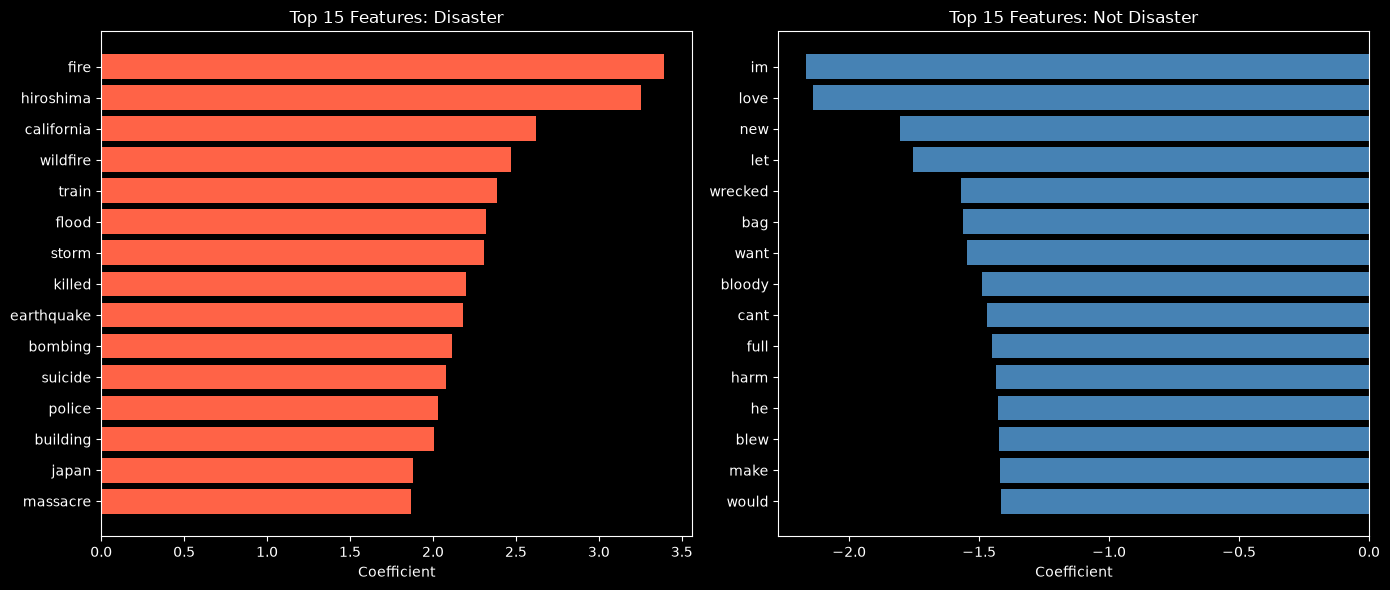

In [22]:
import matplotlib.pyplot as plt

# Select top 15 for each class
top15_disaster = top_disaster.head(15)
top15_non_disaster = top_non_disaster.head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Disaster class
axes[0].barh(top15_disaster["feature"], top15_disaster["coefficient"], color="tomato")
axes[0].set_title("Top 15 Features: Disaster")
axes[0].set_xlabel("Coefficient")
axes[0].invert_yaxis()

# Non-disaster class
axes[1].barh(top15_non_disaster["feature"], top15_non_disaster["coefficient"], color="steelblue")
axes[1].set_title("Top 15 Features: Not Disaster")
axes[1].set_xlabel("Coefficient")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Error analysis

- False Negatives refer to actual disaster tweets that were incorrectly classified as non-disaster.
- The disaster class (label 1) is treated as the positive class throughout this analysis, as it represents the event of interest that the model is designed to detect.

In [23]:
# Add original text to error DataFrame using index alignment
error_df = pd.DataFrame({
    "text_original": df.loc[X_test.index, "text"].values,
    "text_clean": X_test.values,
    "y_true": y_test.values,
    "y_pred": y_pred
})

# False Negatives
false_negatives = error_df[(error_df["y_true"] == 1) & (error_df["y_pred"] == 0)]

# False Positives
false_positives = error_df[(error_df["y_true"] == 0) & (error_df["y_pred"] == 1)]

print("False Negatives:\n")
print(false_negatives.head(20))
print("\nFalse Positives:\n")
print(false_positives.head(20))

False Negatives:

                                         text_original  \
5    Hollywood Movie About Trapped Miners Released ...   
6    Thu Aug 06 2015 01:20:32 GMT+0000 (UTC)\n#mill...   
7        I can't drown my demons they know how to swim   
13   @XHNews We need these plants in the pacific du...   
16   'It looks like a mudslide' poor thing! ?? #gre...   
22   on the flip side I'm at Walmart and there is a...   
26   Bomb head? Explosive decisions dat produced mo...   
27   I agree with certain cultural appropriation th...   
29   The Dress Memes Have Officially Exploded On Th...   
30   Aquarium Ornament Wreck Sailing Boat Sunk Ship...   
42   Newlyweds feed thousands of Syrian refugees in...   
44   My prediction for the Vikings game this Sunday...   
48   A subcontractor working for French seismic sur...   
59   #hot  Funtenna: hijacking computers to send da...   
81   @leedsrouge Love what you picked! We're playin...   
84   @PrablematicLA @Adweek I'm actually currently ...

## Error Analysis

### Data Quality Issues

A manual inspection of a random sample of false negatives and false positives
reveals two distinct issues that complicate the error analysis.

**(a) Labeling Errors**

A non-negligible share of misclassified tweets appear to be mislabeled in
the dataset. Examples:

* "I can't drown my demons they know how to swim": a well-known lyric with
  no disaster-related content, labeled as disaster
* "'It looks like a mudslide' poor thing! #greatbritishbakeoff": a comment
  about a baking show, labeled as disaster
* "We need these plants in the pacific during the cyclone seasons it would
  help": a political comment about wind energy, labeled as disaster

In these cases the model prediction is arguably more accurate than the
ground truth label, highlighting the inherent noise in crowdsourced
annotation. These tweets are counted as false negatives in the evaluation,
but are better described as true negatives given the incorrect labels.

**(b) Ambiguous and Fragmentary Language**

A further subset of tweets is written in heavily fragmented, dialectal or
cryptic language that makes even manual classification difficult:

* "Bomb head? Explosive decisions dat produced more dead children than dead
  bodies trapped tween buildings on that day in September": likely a
  reference to 9/11 or civilian casualties of military action, but the
  fragmentary style leaves substantial room for interpretation

The wide interpretive margin in such cases means that model errors on
these tweets are difficult to attribute to either the model or the label.

### Pragmatic Decision

Labels are treated as correct for the remainder of this analysis. This
is a simplification that does not fully reflect the data quality issues
observed above, but is necessary to keep the scope manageable.

### Interpretation

**False Negatives: real disaster content missed by the model**

The dominant pattern among false negatives is real disaster or crisis content
framed in neutral or informal language that lacks the high-weight disaster
keywords the model relies on. Without terms like "earthquake", "wildfire" or
"flood", TF-IDF has no signal to classify these tweets correctly:

* "Newlyweds feed thousands of Syrian refugees instead of hosting a banquet":
  humanitarian crisis described in neutral everyday language
* "A subcontractor working for CGG has been kidnapped in Cairo and is held
  by Islamic State": a real crisis event written in neutral news language
* Tweets written in heavy dialect or informal style further reduce the overlap
  with the disaster vocabulary the model has learned

**False Positives: non-disaster content interpreted as disaster by the model**

High-weight disaster terms appearing in non-disaster contexts drive the
majority of false positives:

* "slicker than an oil spill", "Mercury Cyclone GT"
  (car model), "two hours of Sandstorm remixes" (music track),
  "if firefighters acted like cops shooting a flamethrower" (hypothetical)
  all contain high-weight disaster terms in non-disaster contexts

These failure modes would be partially addressed by contextualised
embeddings such as Sentence-BERT, which represent words differently
depending on their surrounding context.

# Conclusion

This project developed a text classification pipeline to distinguish between
tweets reporting real disasters and those that do not. The pipeline consists
of a text preprocessing step, TF-IDF vectorization and Logistic Regression
as the classifier, with hyperparameter tuning via 10-fold cross-validation.

The final model achieves a weighted average F1 score of 0.81 on the held-out
test set, with stable cross-validation performance (mean F1 0.794, std 0.018),
suggesting good generalisation. Threshold optimization further allows trading
precision for recall depending on the deployment context: lowering the
threshold to 0.358 increases disaster class recall from 0.71 to 0.85 at the
cost of a moderate precision drop.

The error analysis reveals that the model relies on high-frequency
disaster-related terms as identified in the feature importance analysis.
While these features are semantically plausible, TF-IDF optimises purely
on statistical co-occurrence and could in principle assign high weights to
arbitrary terms that happen to correlate with a label in the training data.
The model systematically fails on non-literal language and neutral framing
of real events. A non-negligible share of misclassifications can additionally
be attributed to labeling noise in the original dataset.

As a next step, contextualised embedding methods such as Sentence-BERT could
partially address the context-blindness of TF-IDF. However, for short,
keyword-driven texts like tweets, the expected performance gain without
fine-tuning is modest, and the TF-IDF baseline proves to be a strong and
interpretable solution for this task.